In [2]:
import pandas as pd

# 1. Load the dataset from the CSV file
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. Drop zero-variance features (columns that contain only one unique value)
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

# 3. Check the shape of the dataframe after cleaning
print("Current dataset shape (Rows, Columns):", df.shape)

# 4. Display the first 5 rows to verify the changes
df.head()

Current dataset shape (Rows, Columns): (1470, 32)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


In [3]:
# 5. Check for missing values in the dataset
print("\n--- MISSING VALUES ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Only print columns with missing data

# 6. Display basic statistical details (mean, min, max, etc.) of numeric columns
print("\n--- STATISTICAL SUMMARY ---")
df.describe().T # Transposed for better readability


--- MISSING VALUES ---
Series([], dtype: int64)

--- STATISTICAL SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.00,3.0,4.00,4.0



--- ATTRITION PERCENTAGE ---
Attrition
No     83.88%
Yes    16.12%
Name: proportion, dtype: object


/tmp/ipykernel_760/3979731996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='Set2')


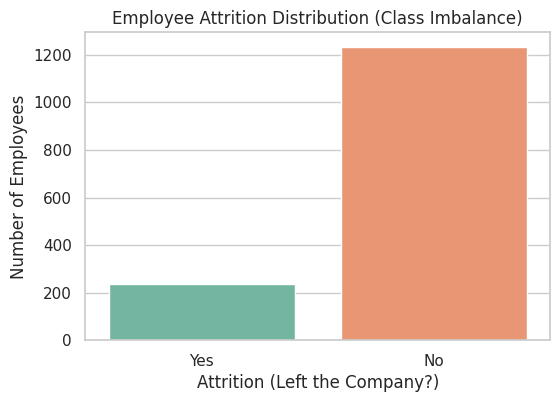

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style for the plots
sns.set_theme(style="whitegrid")

# 2. Create a figure and plot the Attrition count
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='Set2')

# 3. Add titles and labels for clear presentation
plt.title('Employee Attrition Distribution (Class Imbalance)')
plt.xlabel('Attrition (Left the Company?)')
plt.ylabel('Number of Employees')

# 4. Calculate and print the exact percentage of each class
print("\n--- ATTRITION PERCENTAGE ---")
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_pct.round(2).astype(str) + '%')

# 5. Display the chart
plt.show()

<Axes: xlabel='Attrition', ylabel='count'>

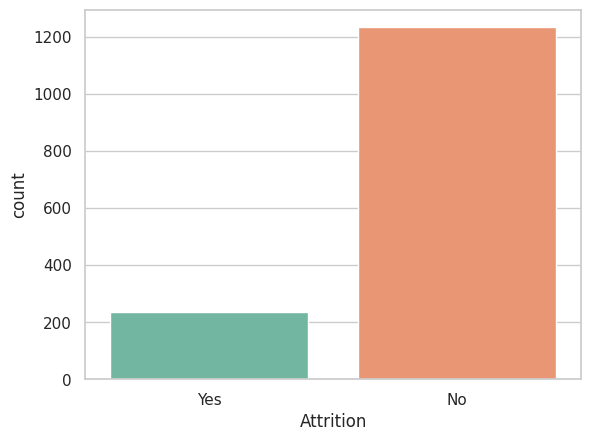

In [5]:
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='Set2', legend=False)

In [6]:
# 1. Binary Encoding: Convert binary categorical columns to 1s and 0s
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# 2. One-Hot Encoding: Convert categorical columns with >2 values into dummy variables
# drop_first=True helps prevent the "dummy variable trap" (multicollinearity)
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Verify the new dataset shape and preview the encoded data
print("New dataset shape after encoding (Rows, Columns):", df.shape)
df.head()

New dataset shape after encoding (Rows, Columns): (1470, 46)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,2,0,94,3,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,2,3,1,61,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,4,1,92,2,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,5,4,0,56,3,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,7,1,1,40,3,...,False,True,False,False,False,False,False,False,True,False


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target variable (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# 2. Split the data into Training (80%) and Testing (20%) sets
# stratify=y ensures the 84/16 imbalance is strictly maintained in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the numerical features (crucial for models like SVM and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Only transform the test set to prevent data leakage

# 4. Verify the splits
print("Training data shape (Features, Labels):", X_train_scaled.shape, y_train.shape)
print("Testing data shape (Features, Labels):", X_test_scaled.shape, y_test.shape)

Training data shape (Features, Labels): (1176, 45) (1176,)
Testing data shape (Features, Labels): (294, 45) (294,)


--- TRAINING DATA AFTER SMOTE ---
Attrition
0    986
1    986
Name: count, dtype: int64

--- MODEL EVALUATION (LOGISTIC REGRESSION) ---
Overall Accuracy: 0.77

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.80      0.85       247
           1       0.37      0.62      0.46        47

    accuracy                           0.77       294
   macro avg       0.64      0.71      0.66       294
weighted avg       0.83      0.77      0.79       294



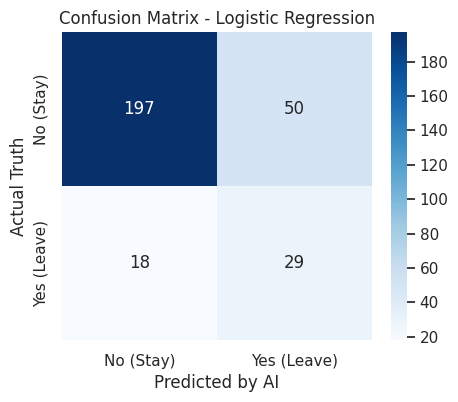

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Apply SMOTE strictly to the TRAINING data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("--- TRAINING DATA AFTER SMOTE ---")
print(y_train_smote.value_counts())

# 2. Initialize and train the Logistic Regression model
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_smote, y_train_smote)

# 3. Predict on the unseen TESTING data (the 294 hidden employees)
y_pred = model_lr.predict(X_test_scaled)

# 4. Evaluate the model's performance
print("\n--- MODEL EVALUATION (LOGISTIC REGRESSION) ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred))

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No (Stay)', 'Yes (Leave)'], yticklabels=['No (Stay)', 'Yes (Leave)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Truth')
plt.show()


--- MODEL EVALUATION (SUPPORT VECTOR MACHINE) ---
Overall Accuracy: 0.83

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       247
           1       0.47      0.36      0.41        47

    accuracy                           0.83       294
   macro avg       0.68      0.64      0.66       294
weighted avg       0.82      0.83      0.82       294



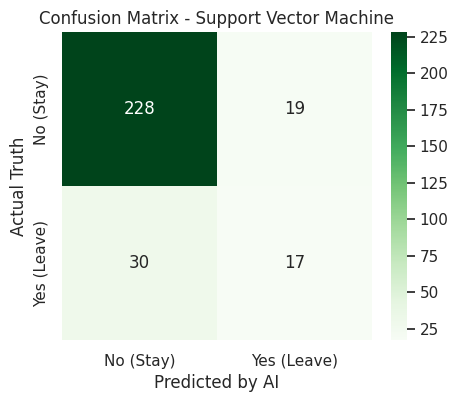

In [9]:
from sklearn.svm import SVC

# 1. Initialize and train the Support Vector Machine (SVM) model
# Using default RBF kernel which is good for complex, non-linear data
model_svm = SVC(random_state=42)
model_svm.fit(X_train_smote, y_train_smote)

# 2. Predict on the unseen TESTING data
y_pred_svm = model_svm.predict(X_test_scaled)

# 3. Evaluate the SVM model's performance
print("\n--- MODEL EVALUATION (SUPPORT VECTOR MACHINE) ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

# 4. Visualize the Confusion Matrix for SVM
plt.figure(figsize=(5, 4))
cm_svm = confusion_matrix(y_test, y_pred_svm)
# Changed color map to 'Greens' to distinguish from Logistic Regression
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=['No (Stay)', 'Yes (Leave)'], yticklabels=['No (Stay)', 'Yes (Leave)'])
plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Truth')
plt.show()